<div style="box-sizing:border-box;max-width:100%;margin:0 0 8px;padding:4px 0;color:inherit;line-height:1.35;"><img src="https://thetahat.ru/images/logo_thetahat.png" alt="ThetaHat" style="display:block!important;width:52px!important;max-width:52px!important;height:auto!important;margin:0 0 9px 0!important;padding:0!important;"><div style="display:flex;align-items:center;justify-content:space-between;flex-wrap:wrap;gap:8px 12px;"><span style="min-width:0;color:inherit;font-size:12px;font-weight:700;letter-spacing:0.055em;text-transform:uppercase;"><a href="https://thetahat.ru/courses/ysda-group" style="color:inherit;text-decoration:none;">Школа анализа данных</a>&nbsp;·&nbsp;Машинное обучение</span></div></div>

<h2><span style="display:block;box-sizing:border-box;max-width:100%;padding:16px 22px 17px;border-radius:14px;background:linear-gradient(135deg,#D4470E 0%,#C7324E 50%,#B316B8 100%);color:#FFFFFF;line-height:1.15;font-weight:500;">Домашнее задание 2. Линейная регрессия.</span></h2>

<div style="box-sizing:border-box;max-width:100%;margin:18px 0 26px;padding:18px 20px;border:1px solid rgba(127, 127, 127, 0.28);border-left:4px solid #F13A3F;border-radius:12px;background:rgba(127, 127, 127, 0.07);color:inherit;">
  <div style="color:inherit;font-size:12px;font-weight:800;letter-spacing:0.08em;text-transform:uppercase;">Общие правила</div>
  <ul style="margin:10px 0 0;padding-left:22px;line-height:1.55;">
    <li>Выполненную работу <strong>в формате <code>ipynb</code></strong> нужно отправить в кабинете студента <a href="https://thetahat.ru/"><strong>на сайте ThetaHat</strong></a>. Инструкция по регистрации на сайте, записи на курс и сдаче домашек есть на странице курса в ЛМС. <strong>Работы, присланные иным способом, не принимаются.</strong> Дедлайны указаны в личном кабинете, они являются строгими.</li>
    <li>Обязательно изучите <a href="https://thetahat.ru/courses/design-hw"><strong>руководство по оформлению ДЗ</strong></a>. В частности, оно содержит примеры случаев, когда могут быть снижены баллы.</li>
    <li>Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><strong>правила использования ИИ-инструментов</strong></a> при решении домашнего задания.</li>
    <li>Выполнять задание необходимо полностью самостоятельно. <strong>При обнаружении списывания (в т.ч. злоупотребление ИИ) всем участникам списывания дается штраф согласно правилам на странице курса.</strong></li>
    <li>Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/thetagrader"><img src="https://thetahat.ru/images/ai_eval_small.png" style="display:inline;vertical-align:middle;" alt="ThetaGrader"></a> <a href="https://thetahat.ru/thetagrader"><strong>ThetaGrader</strong></a>. Результаты проверки будут отправлены вам в течение 1-2 суток после дедлайна. После вы можете исправить ошибки или аргументировать свое мнение и отправить на проверку проверяющему. Подробнее на странице курса в ЛМС.</li>
    <li>Никакой код из данного задания при проверке запускаться не будет. <em>Если код не выполнен, недописан и т.д., то он не оценивается.</em></li>
  </ul>
  </br>
    
  <div style="color:inherit;font-size:12px;font-weight:800;letter-spacing:0.08em;text-transform:uppercase;">Правила заполнения ноутбука</div>
  <ul style="margin:8px 0 0;padding-left:22px;line-height:1.55;">
    <li>Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения существующих ячеек.</li>
    <li>Отвечайте на вопросы, а также добавляйте новые ячейки в любом количестве в предложенных местах, которые обозначены <code>&lt;...&gt;</code>.</li>
    <li>Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз. Комментарии к решению пишите в markdown-ячейках. Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.</li>
    <li>В markdown-ячейках, содержащих описание задачи, находятся специальные отметки, которые <strong style="color:red;">запрещается модифицировать</strong>.</li>
    <li>Решение теоретических задач оформляйте в markdown-ячейках в формате $\LaTeX$. При решении можно использовать ИИ-инструменты для оформления написанного самостоятельно решения, например, написать черновик формул и попросить ИИ оформить эти формулы в $\LaTeX$.</li>
    <li>При нарушении данных правил работа может получить 0 баллов.</li>
  </ul>
</div>

## 🔵 <font color="blue">Часть L</font>

Дедлайн по части M во вторник 29.09 в 16:00. Дедлайн по этой части **в субботу 03.10 в 23:59**. Подробнее в описании курса в ЛМС.


**Баллы эту часть задания:**

* Задача 2 &mdash; 30 баллов;
* Задача 3 &mdash; 30 баллов;
* Задача 4 &mdash; 30 баллов;
* Задача 5 &mdash; 40 баллов.

In [1]:
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

sns.set(style="whitegrid", palette="Set2")

In [ ]:
# Bot check

# HW_ID: ysda_ml1_task2
# Система проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так система проверит, что ты ничего не перепутал, и отправляешь финальную версию,
# а не промежуточную. После отправки работы со статусом final до дедлайна все 
# еще можно вносить исправления и отправлять повторно.

# Никакие значения в этой ячейке не влияют на факт сдачи работы.

---

### Ссылки на использование ИИ

Если при решении задач использовался ИИ, укажи здесь публичные ссылки на все чаты с ИИ и поясни, для каких целей он применялся. Обрати внимание на <a href="https://thetahat.ru/courses/ai-rules" target="_top">правила</a>.

**Задача 1**
1. ссылка
    - для чего использована
    - для чего использована
2. ссылка
    - для чего использована

**Задача 2**
1. ссылка
    - для чего использована


---
### <span style="display:inline-block;padding:6px 13px;border-radius:999px;background:linear-gradient(135deg,#D4470E 0%,#C7324E 55%,#B316B8 100%);color:#FFFFFF;font-size:16px;font-weight:700;line-height:1.2;">Задача 2</span>


*Теперь давайте углубимся в теорию градиентных методов оптимизации. Эти подходы будут часто встречаться, поэтому важно освоить их применение. Для этого применим градиентные методы в другом методе обучения линейной регрессии.*

*В этой задаче ожидается теоретическое решение, реализация метода не предполагается.*

Рассмотрим линейную регрессию $y(x) = x^T \theta$, причем для оценки $\theta$ будем рассматривать функцию потерь Хьюбера
$$R(x) = \frac{x^2}{2} I\{|x| \leqslant c\} + c\left(|x| - \frac{c}{2}\right)I\{|x| > c\}.$$

Тем самым задача оптимизации имеет вид
$$\sum_{i=1}^n R(Y_i - x_i^T \theta) \longrightarrow \min_{\theta \in \mathbb{R}^d}.$$

**1.** Нарисуйте график $R(x)$. В чем польза выбора такой функции потерь?

<br/>
<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Кликни для показа подсказки</summary>

1. Подумайте, что происходит в случае больших отклонений предсказаний от истины? Что это за точки?
    
2. Обратите внимание на поведение $R(x)$ в точке $x=c$.
</details>

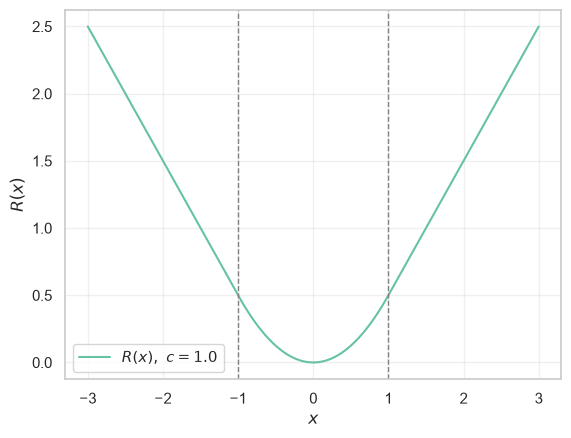

In [2]:
c = 1.0
x = np.linspace(-3, 3, 1_000)

R = np.where(
    np.abs(x) <= c,
    x**2 / 2,
    c * (np.abs(x) - c / 2),
)

plt.plot(x, R, label=rf"$R(x),\ c={c}$")
plt.axvline(-c, color="gray", linestyle="--", linewidth=1)
plt.axvline(c, color="gray", linestyle="--", linewidth=1)
plt.xlabel("$x$")
plt.ylabel("$R(x)$")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

1. Для больших отклонений функция ведет себя линейно. Это позволяет не переобучать модель на выбросах в данных (как в случае с квадратичной функцией).
2. Для малых x функция ведет себя квадратично, типичный выбор для евклидовых пространств.
3. Функция также имеет непрерывную первую производную.

**2.** Выпишите формулы градиентного спуска (GD) и стохастического градиентного спуска (SGD).

...

---
### <span style="display:inline-block;padding:6px 13px;border-radius:999px;background:linear-gradient(135deg,#D4470E 0%,#C7324E 55%,#B316B8 100%);color:#FFFFFF;font-size:16px;font-weight:700;line-height:1.2;">Задача 3</span>


*Как говорилось на лекции, в стохастическом градиентном спуске (SGD) важно использовать несмещенные оценки градиента. Давайте посмотрим, как ведет себя SGD, если использовать смещенные оценки.*

Пусть случайная величина $X$ имеет нормальное распределение с параметрами $(a, \sigma^2)$, то есть:
$$
X \sim \mathcal{N}(a, \sigma^2)
$$
Рассмотрим следующую задачу оптимизации:
$$
f(a, \sigma) = (\mathsf{E}X-1)^2 + (\mathsf{D}X - 1)^2 \longrightarrow \min_{a, \sigma}
$$
В данном случае правильный ответ мы можем легко найти непосредственно, однако в реальности возникают гораздо более сложные функции, и решить задачу напрямую руками не представляется возможным. Для решения таких задач применяются различные градиентные методы, такие как, например, стохастический градиентный спуск. Оказывается, что в нём критически важно использовать несмещенные оценки градиента.

*Замечание.* Если смещение заключается только в том, что математическое ожидание оценки отличается от вектора градиента домножением каждой компоненты на одну и ту же константу, то проблем нет &mdash; все равно мы используем шаг градиента.

В данной задаче вам предлагается на примере простой функции убедиться, насколько важным оказывается использовать несмещенные оценки в итерационных процедурах.

**Решение:**

Запишите оптимальные значения параметров $a$ и $\sigma^2$, а также шаг простого градиентного спуска (не стохастического) для минимизации определенной выше функции $f(a, \sigma)$ по параметрам $a$ и $\sigma$:

<br/>
<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Кликни для показа подсказки</summary>
Просто вырази функцию $f$ через $a$ и $\sigma$ и запиши шаг градиентного спуска для этих параметров.
</details>

...

Реализуйте метод простого градиентного спуска для выше описанной задачи оптимизации, выбрав некоторое начальное приближение параметров. Для каждой итерации сохраните текущие значения среднего и дисперсии, постройте график зависимости значений $a$ и $\sigma^2$ от шага процедуры. Наблюдается ли сходимость к оптимальным параметрам?

In [ ]:
...

Теперь предположим, что мы хотим оценить градиент стохастически. Например, давайте текущие значения среднего и дисперсии оценивать изученным ранее методом Монте-Карло. А именно, каждый раз мы будем генерировать выборку размера 5 из нормального распределения с текущими значениями параметров и далее по ней оценивать градиент.
Для оценки математического ожидания ипользуйте несмещенную оценку 
$$\widehat{a} = \overline{X} := \frac{1}{n}\sum_{i=1}^n X_i,$$
а для дисперсии &mdash; смещенную 
$$\widehat{\sigma}^2 = S^2 := \frac{1}{n}\sum_{i=1}^n \left(X_i - \overline{X}\right)^2.$$

Реализуйте описанный выше подход. Как и прежде, изобразите текущие значения параметров в зависимости от итерации. Сошлась ли такая процедура к оптимальным значениям?

In [ ]:
...

Теперь изменим нашу процедуру, взяв несмещенную оценку для дисперсии
$$\widehat{\sigma}^2 = S^2_{u} := \frac{1}{n-1}\sum_{i=1}^n \left(X_i - \overline{X}\right)^2.$$

Обратите внимание на параметр `ddof` в функции `np.var`.

Поменялся ли результат?

In [ ]:
...

**Вывод:**

...

---
### <span style="display:inline-block;padding:6px 13px;border-radius:999px;background:linear-gradient(135deg,#D4470E 0%,#C7324E 55%,#B316B8 100%);color:#FFFFFF;font-size:16px;font-weight:700;line-height:1.2;">Задача 4</span>


*Наконец, рассмотрим, как можно использовать стохастические градиентные методы при оптимизации сложных функций.*

Некоторая ML-модель имеет один параметр $\theta$, который обучается посредством *оптимизации* функции
$$\mathcal{L}(\theta) = \mathsf{E} \exp\left(-\frac{\xi^2\sqrt{\eta}}{1+\theta^2}\right),$$
где $\xi$ имеет стандартное нормальное распределение, а $\eta$ &mdash; пуассоновское распределение с параметром 5 и не зависит от $\xi$.


Оптимизируйте эту функцию, используя стохастический градиентный спуск. Необходимо вывести формулы и реализовать их.

<br/>
<details style="box-sizing:border-box;max-width:100%;margin:0 0 18px;padding:8px 14px 10px;border:1px solid rgba(199,50,78,0.20);border-radius:10px;color:inherit;">

<summary style="cursor:pointer;color:inherit;font-size:13px;font-weight:750;text-decoration:underline;text-decoration-color:#C7324E;text-decoration-thickness:1.5px;text-underline-offset:3px;">Кликни для показа подсказки</summary>
Дифференцирование и мат. ожидание можно менять местами. Далее, обрати внимание на метод Монте-Карло с лекции, с его помощью можно оценить мат. ожидание.
</details>

In [ ]:
...

---
### <span style="display:inline-block;padding:6px 13px;border-radius:999px;background:linear-gradient(135deg,#D4470E 0%,#C7324E 55%,#B316B8 100%);color:#FFFFFF;font-size:16px;font-weight:700;line-height:1.2;">Задача 5</span>


*Устали писать формулы? Самое время что-то закодить! Давайте закодим то, что вывели во 2-й задаче.*

В этой задаче вам предлагается реализовать регрессию Хьюбера, а также применить ее к данным с выбросами. Для начала реализуйте класс по шаблону снизу. Обратите внимание, что класс `HuberRegression` &mdash; наследник класса `BaseEstimator`, это с легкостью позволит использовать наш класс в различных пайплайнах библиотеки `sklearn`.

**1.** Реализуйте класс. **При реализации класса запрещено пользоваться ИИ-инструментами.**

In [ ]:
# При реализации класса запрещено пользоваться ИИ-инструментами.

from sklearn.base import BaseEstimator

class HuberRegression(BaseEstimator):
    """Класс, реализующий линейную регрессию с функцией потерь Хьюбера."""

    def __init__(self, c: float = 1.0, fit_intercept: bool = True, max_iter: int = 1000) -> None:
        """Инициализирует модель.

        Параметры: c (float): Константа из функции потерь Хьюбера.
        fit_intercept (bool): Добавлять ли константный признак. max_iter
        (int): Максимальное число итераций оптимизации.
        """
        self.c = c
        self.fit_intercept = fit_intercept
        self.max_iter = max_iter

    def fit(self, X: np.ndarray, y: np.ndarray) -> "HuberRegression":
        """Обучает модель.

        Параметры:
        X (np.ndarray): Матрица признаков.
        y (np.ndarray): Вектор целевой переменной.

        Возвращает:
        HuberRegression: Обученная модель.
        """
        if X.shape[0] != y.shape[0]:
            raise ValueError("Количество строк в X и y должно совпадать")

        ...

        self.coef_ = ...  # Коэффициенты модели
        self.intercept_ = ...  # Свободный коэффициент
        self.n_iter_ = ...  # Число итераций

        return self

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Делает предсказание на новых данных.

        Параметры: X (np.ndarray): Матрица признаков.

        Возвращает: np.ndarray: Вектор предсказанных значений.
        """

        if X_copy.shape[1] != self.coef_.shape[0]:
            raise ValueError("Число признаков в X не соответствует числу коэффициентов модели")

        ...
        return pred

**2.** Загрузите данные из файлов <a href="https://thetahat.ru/files/ad/main/3/train.csv"><code>train.csv</code></a>, <a href="https://thetahat.ru/files/ad/main/3/test.csv"><code>test.csv</code></a>. Не забудьте, что всю аналитику, а также процесс обучения и подбор гиперпараметров необходимо выполнять на обучающей выборке.

In [ ]:
...

Посмотрите на зависимость целевой переменной от каждого признака.

In [ ]:
...

Что можно сказать о наличии возможных выбросов? Какое влияние они могут оказать? 

...

**3.** Обучите простую линейную регрессию и посчитайте качество на тестовой выборке по метрике [MSE](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html#sklearn.metrics.mean_squared_error).

In [ ]:
...

Что можно сказать о качестве нашей модели?

...

**4.** Теперь обучите линейную регресcию Хьюбера и посчитайте качество на тестовой части по метрикe MSE.

In [ ]:
...

Что изменилось?

...

**5.** Для обучающей выборки постройте два графика (по графику на каждую модель), на которых изобразите зависимость истинного и предсказанного значения таргета от каждого признака.

In [ ]:
...

Что можно заметить на этих графиках?

...

**Вывод:**

...

<div style="box-sizing:border-box;max-width:100%;margin-top:42px;padding:18px 0 4px;border-top:1px solid rgba(127, 127, 127, 0.28);color:inherit;font-size:0.9em;line-height:1.5;"><img src="https://thetahat.ru/images/logo_thetahat.png" alt="ThetaHat" style="display:block!important;width:34px!important;max-width:34px!important;height:auto!important;margin:0 0 9px 0!important;padding:0!important;">© 2026 команда <a href="https://thetahat.ru/" style="color:inherit;font-weight:750;text-decoration:underline;text-decoration-color:#F13A3F;text-underline-offset:3px;">ThetaHat</a> для курса ML-1 ШАД</div>